In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05: return 'positive'
    elif score <= -0.05: return 'negative'
    else: return 'neutral'

from transformers import pipeline
classifier = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment")

C:\Users\lars\Documents\School\group50-text-mining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 22330.81it/s]


In [ ]:
import pandas as pd

# 1. Load the dataframe (adjust path if needed)
df = pd.read_csv("C:/Users/lars/Documents/School/group50-text-mining/Poster project/test_sets/Sentiment-topic-test.tsv", sep="\t")

# Replace 'text' with the actual column name of your sentences if it's different
text_column = "text"

# 2. Apply your existing VADER function
print("Running VADER...")
df["vader_prediction"] = df[text_column].apply(get_vader_sentiment)

# 3. Apply your existing RoBERTa pipeline
print("Running RoBERTa...")


def run_roberta(text):
    try:
        # Truncate text to 512 tokens to prevent model breaking on long sentences
        result = classifier(str(text)[:512])[0]
        return result["label"].lower()
    except Exception:
        return "error"


df["roberta_prediction"] = df[text_column].apply(run_roberta)

# 4. Create the disagreement column for your poster analysis
df["disagreement"] = df["vader_prediction"] != df["roberta_prediction"]

# 5. Save the output
df.to_csv("sentiment_comparison_results.csv", index=False)
print("Done! Results saved to 'sentiment_comparison_results.csv'")

Saved: model_accuracy_comparison.png
Saved: model_disagreement.png

   🔍 CRITICAL ERROR ANALYSIS EXAMPLES (WHERE THE MODELS DISAGREED)   
Sentence ID 2: "This Italian place is really trendy but they have forgotten about the most important part of a restaurant, the food."
   • True Ground-Truth Label : NEGATIVE
   • VADER Prediction       : POSITIVE
   • RoBERTa Prediction     : NEUTRAL
--------------------------------------------------------------------------------
Sentence ID 4: "The story of this movie is focused on Carl Brashear played by Cuba Gooding Jr. who wants to be the first African American deep sea diver in the Navy."
   • True Ground-Truth Label : NEUTRAL
   • VADER Prediction       : POSITIVE
   • RoBERTa Prediction     : NEUTRAL
--------------------------------------------------------------------------------
Sentence ID 5: "Chris O'Donnell stated that while filming for this movie, he felt like he was in a toy commercial."
   • True Ground-Truth Label : NEUTRAL
   • VADER 

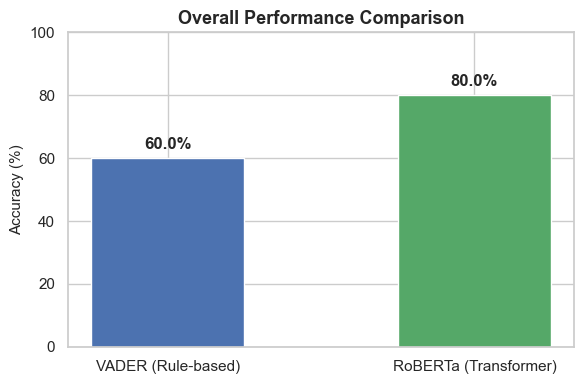

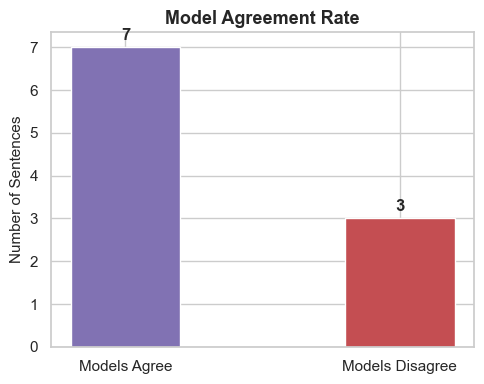

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "C:/Users/lars/Documents/School/group50-text-mining/Poster project/notebooks/sentiment_comparison_results.csv"
df = pd.read_csv(file_path)

label_mapping = {"label_0": "negative", "label_1": "neutral", "label_2": "positive"}
df["roberta_prediction"] = df["roberta_prediction"].str.lower().map(label_mapping)

df["disagreement"] = df["vader_prediction"] != df["roberta_prediction"]
df["vader_correct"] = df["vader_prediction"] == df["sentiment"]
df["roberta_correct"] = df["roberta_prediction"] == df["sentiment"]

vader_accuracy = df["vader_correct"].mean() * 100
roberta_accuracy = df["roberta_correct"].mean() * 100

sns.set_theme(style="whitegrid")
methods = ['VADER (Rule-based)', 'RoBERTa (Transformer)']
accuracies = [vader_accuracy, roberta_accuracy]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(methods, accuracies, color=['#4C72B0', '#55A868'], width=0.5)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Overall Performance Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)

# Add percentage labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/lars/Documents/School/group50-text-mining/Poster project/model_accuracy_comparison.png', dpi=300)
print("Saved: model_accuracy_comparison.png")

# ==========================================================
# 📈 GRAPH 2: Disagreement Breakdown Chart
# ==========================================================
fig, ax = plt.subplots(figsize=(5, 4))
disagreement_counts = df["disagreement"].value_counts()
# Safety check to ensure both exist
agree_count = disagreement_counts.get(False, 0)
disagree_count = disagreement_counts.get(True, 0)

bars = ax.bar(['Models Agree', 'Models Disagree'], [agree_count, disagree_count], color=['#8172B3', '#C44E52'], width=0.4)
ax.set_ylabel('Number of Sentences', fontsize=11)
ax.set_title('Model Agreement Rate', fontsize=13, fontweight='bold')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{int(yval)}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/lars/Documents/School/group50-text-mining/Poster project/model_disagreement.png', dpi=300)
print("Saved: model_disagreement.png")

# ==========================================================
# 🧐 READABLE DISPLAY: Find Errors to Put on Your Poster
# ==========================================================
print("\n" + "="*80)
print("   🔍 CRITICAL ERROR ANALYSIS EXAMPLES (WHERE THE MODELS DISAGREED)   ")
print("="*80)

# Filter out rows where the models actually disagreed
mismatches = df[df["disagreement"] == True]

for idx, row in mismatches.head(10).iterrows():
    print(f"Sentence ID {row['sentence id']}: \"{row['text']}\"")
    print(f"   • True Ground-Truth Label : {row['sentiment'].upper()}")
    print(f"   • VADER Prediction       : {str(row['vader_prediction']).upper()}")
    print(f"   • RoBERTa Prediction     : {str(row['roberta_prediction']).upper()}")
    print("-" * 80)